# 🧬 From-Scratch Hierarchical Clustering: Leukemia Gene Expression Analysis

**Domain:** Bioinformatics & Machine Learning  
**Objective:** To implement an Agglomerative Hierarchical Clustering engine entirely from scratch (without `scikit-learn` core dependencies) to discover latent patient sub-groups (ALL vs. AML) based on high-dimensional genomic data.

## 📌 Project Architecture
1. **Data Preprocessing:** Cleansing and Z-score normalization.
2. **Dimensionality Reduction:** Variance-based feature selection to mitigate the *Curse of Dimensionality*.
3. **Core Engine:** Custom implementation of Agglomerative Clustering using Lance-Williams updates.
4. **Distance Metrics:** Fully vectorized Euclidean (patients) and Pearson (genes) distances.
5. **Evaluation:** Determining optimal $K$ via Elbow Method and Silhouette Score.
6. **Visualization:** Dendrograms and Biclustering Heatmaps.

In [1]:
%pip install matplotlib seaborn scipy scikit-learn pandas numpy

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.0 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import os
import sys

# System and data processing libraries
import numpy as np
import pandas as pd

# Visualization and IPython display
import matplotlib.pyplot as plt
from IPython.display import Image, display

# Import custom core modules
from src.data_preprocessing import load_and_clean_data, normalize_zscore, filter_top_genes_by_variance
from src.metrics import calculate_euclidean_distance, calculate_pearson_distance
from src.clustering import AgglomerativeClustering
from src.visualization import generate_dendrogram, generate_biclustering_heatmap
from src.evaluation import plot_clustering_evaluation

# Define project directories (assuming notebook is at the project root)
PROJECT_ROOT = os.path.abspath(os.getcwd())
DATA_PATH = os.path.join(PROJECT_ROOT, "data", "raw", "data_set_ALL_AML_independent.csv")
RESULTS_DIR = os.path.join(PROJECT_ROOT, "results")

# Ensure the results directory exists
os.makedirs(RESULTS_DIR, exist_ok=True)

# Set global plotting style
plt.style.use('seaborn-v0_8-whitegrid')

## 1. Data Ingestion & Preprocessing
Microarray gene expression data contains severe noise and varying luminescence intensities. To ensure mathematical stability, we perform the following:
* **Data Cleaning:** Removing non-numeric metadata strings.
* **Z-score Normalization:** Standardizing data distribution to $\mu = 0$ and $\sigma = 1$.
* **Feature Selection:** Retaining only the top 50 highly variable genes to extract the core biological signatures.

In [4]:
# Load raw data
print("Loading raw dataset...")
df_raw = load_and_clean_data(DATA_PATH)

# Normalize data
print("Applying Z-score normalization...")
df_norm = normalize_zscore(df_raw, axis=1)

# Feature selection
print("Filtering top 50 genes by variance...")
df_subset = filter_top_genes_by_variance(df_norm, top_n=50)

display(df_subset.head())
print(f"Final Matrix Shape ready for clustering: {df_subset.shape}")

Loading raw dataset...
Applying Z-score normalization...
Filtering top 50 genes by variance...


,39,40,42,47,48,49,41,43,44,45,...,54,57,58,60,61,65,66,63,64,62
Gene Accession Number,,,,,,,,,,,,,,,,,,,,,
U50743_at,1.329809,2.838208,-0.774262,1.445101,-0.976022,-1.048080,0.248951,0.762959,2.050382,1.449905,...,-0.063297,0.133659,0.268166,-0.308292,-1.235428,0.248951,-1.245036,-0.947200,0.556395,-0.567698
Z83735_at,3.199461,-0.399480,-0.054376,-0.633657,-0.011238,-1.459441,-0.109839,-0.122164,0.124339,2.811219,...,-0.639820,0.025738,-0.639820,0.112014,-0.325529,-0.621332,-0.541219,0.512581,-1.163638,-0.584357
U66075_at,-1.245056,-0.187514,0.688735,-4.463004,-0.247945,-0.686069,0.144857,1.731169,0.069318,0.220395,...,0.265718,0.159964,0.039102,0.023995,0.386580,1.489445,0.235503,-0.534992,0.084426,0.734058
X02419_rna1_s_at,0.317676,0.164269,0.119383,0.170519,0.175064,0.110861,0.134724,0.204609,0.130747,0.108020,...,0.189837,0.185860,0.236427,0.193814,0.168814,0.274495,0.200632,0.145519,0.044953,0.068248
D90359_at,-0.052645,0.061454,1.020594,0.122069,0.350266,0.631946,-0.698014,-0.334325,-3.136869,-4.067485,...,-0.170309,0.032929,0.592725,0.086413,0.300347,0.007970,0.018667,0.471495,0.503585,0.517848


Final Matrix Shape ready for clustering: (50, 34)


## 2. Distance Metrics & Clustering Engine (Math Foundations)

Instead of relying on slow `for` loops, our engine utilizes heavily optimized matrix algebra (Vectorization) to compute distances in $\mathcal{O}(N^2)$ space.

### Euclidean Distance (For Patients)
Used to measure the spatial geometric distance between patient profiles. The expansion of the squared binomial is applied to matrices:
$$(A - B)^2 = A^2 + B^2 - 2AB$$

### Pearson Correlation Distance (For Genes)
Used to identify co-expressed genes regardless of their absolute amplitude. We convert the correlation coefficient $r$ into a valid distance metric $d$:
$$d = 1 - r$$

In [5]:
# ---------------------------------------------------------
# Patient Clustering (Columns)
# ---------------------------------------------------------
print("Executing Patient Clustering Engine (Euclidean)...")
X_patients = df_subset.values.T 
patient_labels = df_subset.columns.tolist()

hc_patients = AgglomerativeClustering(linkage='average')
Z_patients = hc_patients.fit(X_patients, calculate_euclidean_distance)

# ---------------------------------------------------------
# Gene Clustering (Rows)
# ---------------------------------------------------------
print("Executing Gene Clustering Engine (Pearson)...")
X_genes = df_subset.values
gene_labels = df_subset.index.tolist()

hc_genes = AgglomerativeClustering(linkage='average')
Z_genes = hc_genes.fit(X_genes, calculate_pearson_distance)

print("Clustering algorithms converged successfully.")

Executing Patient Clustering Engine (Euclidean)...
Executing Gene Clustering Engine (Pearson)...
Clustering algorithms converged successfully.


## 3. Algorithm Evaluation: Determining Optimal $K$
To mathematically prove the existence of distinct disease sub-types (ALL vs. AML) without human bias, we employ two distinct evaluation strategies simultaneously:
1.  **Elbow Method:** Analyzing the leap in linkage distance when forcing dissimilar clusters to merge.
2.  **Silhouette Score:** Measuring intra-cluster cohesion against inter-cluster separation.

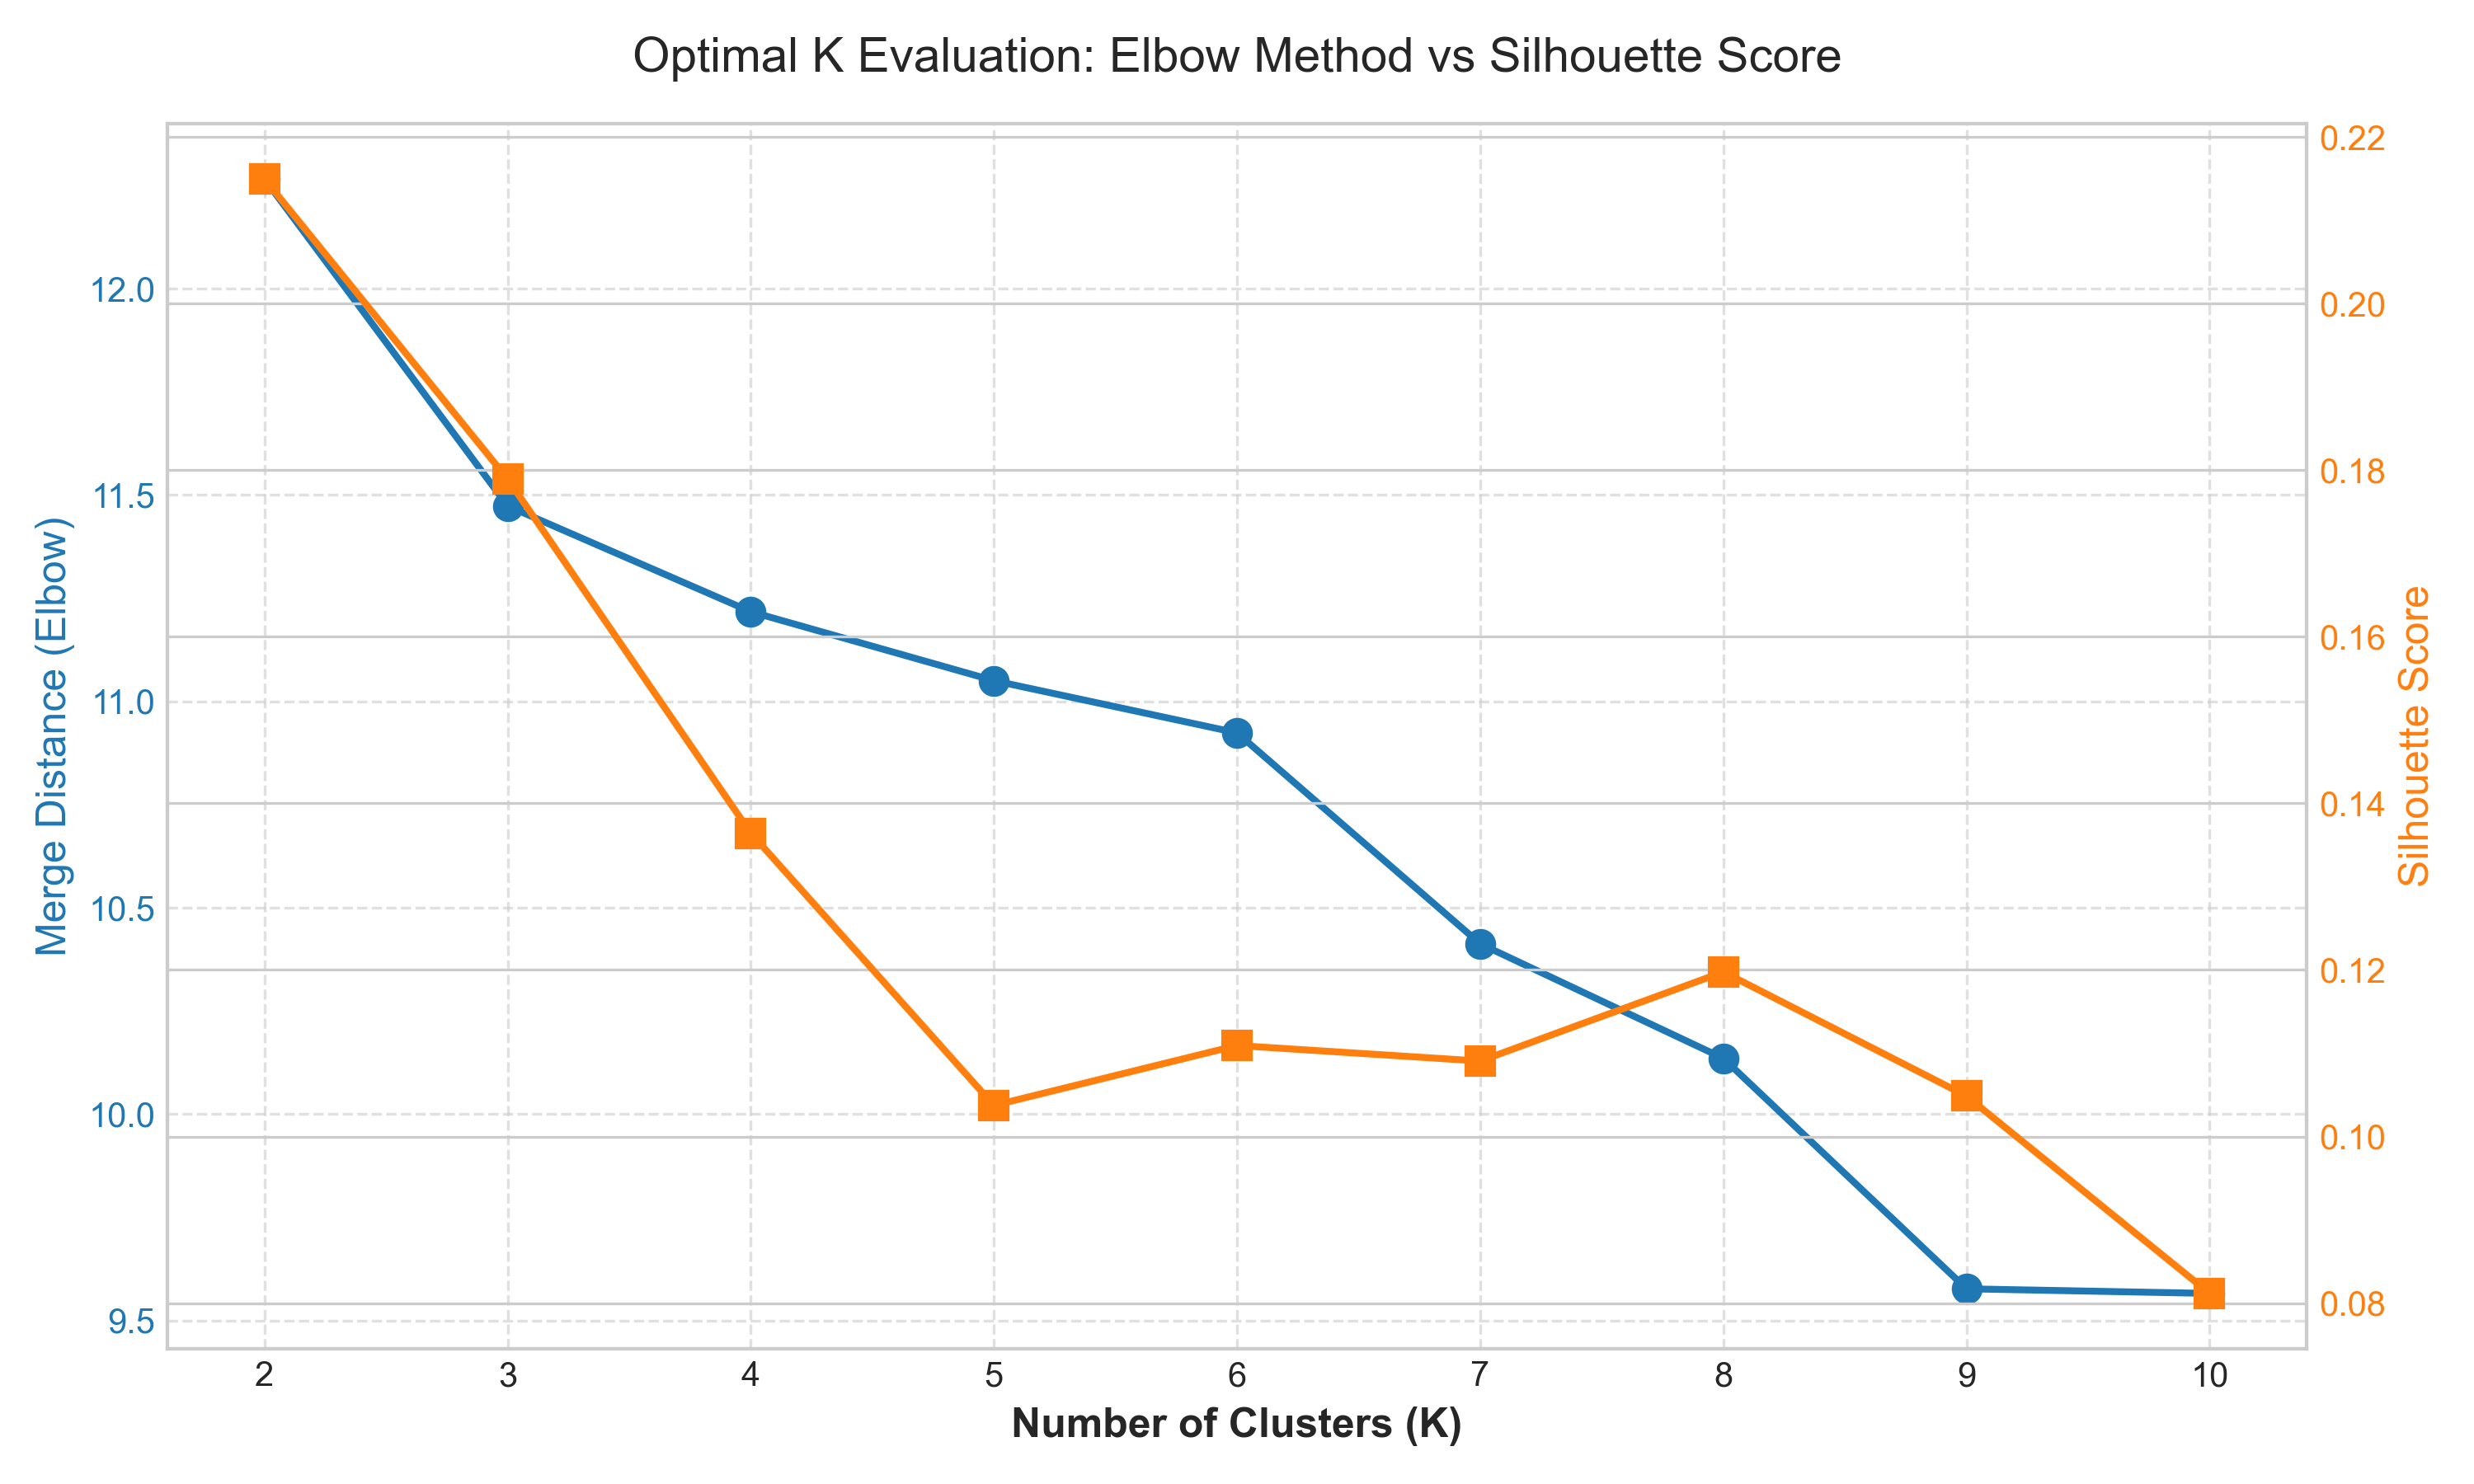

In [6]:
eval_path = os.path.join(RESULTS_DIR, "patients_evaluation_k.png")

# Run evaluation
plot_clustering_evaluation(X_patients, Z_patients, max_k=10, export_path=eval_path)

# Display the exported artifact inline
display(Image(filename=eval_path, width=800))

## 4. Biological Visualization (Insights & Conclusion)
The final step synthesizes both patient and gene dendrograms into a unified **Biclustering Heatmap**. 
* **Red zones** indicate upregulated genes.
* **Blue zones** indicate downregulated genes.
The resulting checkerboard pattern represents the exact "Gene Signatures" distinguishing the patient cohorts.

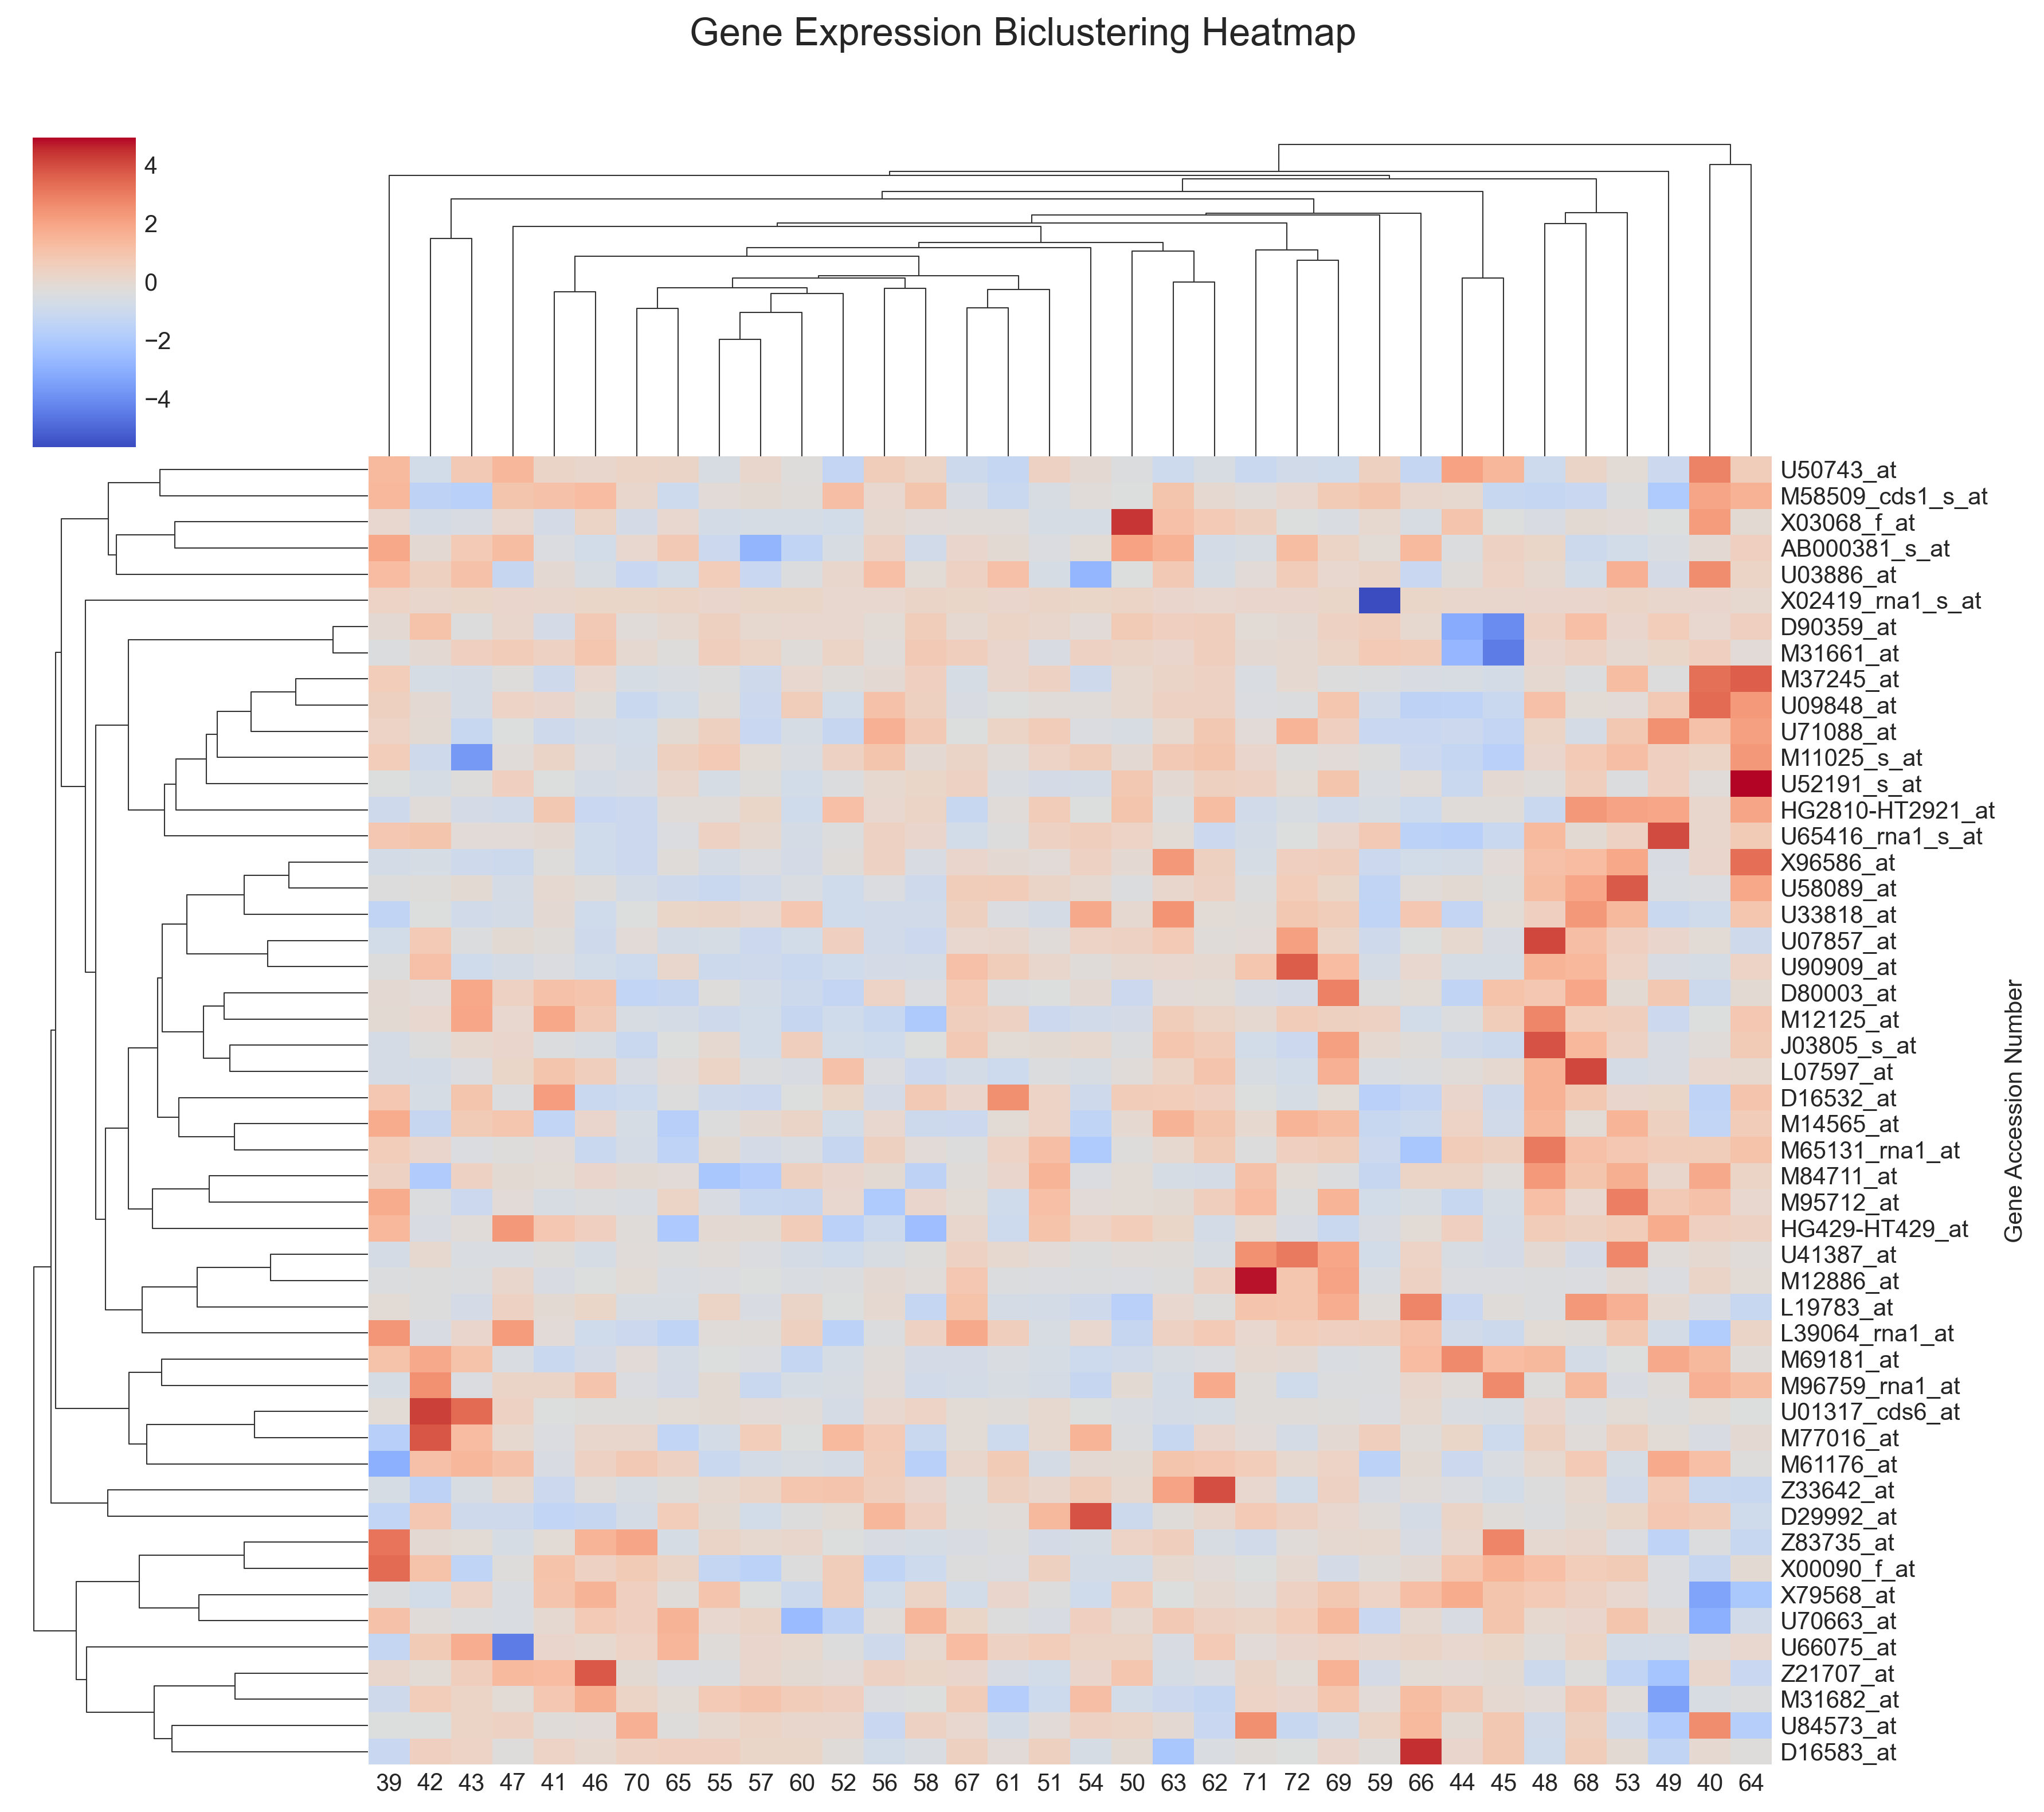

In [7]:
heatmap_path = os.path.join(RESULTS_DIR, "biclustering_heatmap.png")

# Generate heatmap
generate_biclustering_heatmap(
    df_subset, 
    Z_genes, 
    Z_patients, 
    gene_labels, 
    patient_labels, 
    "Gene Expression Biclustering Heatmap", 
    heatmap_path
)

# Display the final artifact inline
display(Image(filename=heatmap_path, width=1000))